In [198]:
import numpy as np
import pandas as pd
import sns
from pandas.core.common import random_state
from scipy.stats import alpha
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

import training
import importlib
import mlflow
from sklearn.linear_model import LogisticRegression, LinearRegression
import dagshub
import ML_Assignment_1.preprocessor as pre

importlib.reload(training)
importlib.reload(pre)
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


In [64]:

dagshub.init(repo_owner='lukaLomadze', repo_name='ML_Assignment_1', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow")



Initialized MLflow to track repo "lukaLomadze/ML_Assignment_1"

Repository lukaLomadze/ML_Assignment_1 initialized!

In [66]:
train= pd.read_csv('../houses/train.csv')
test= pd.read_csv('../houses/test.csv')
print("train : ", train.shape)
print("test : ", test.shape)


train :  (1460, 81)
test :  (1459, 80)


In [67]:
print(train.head(3))
print(test.head(3))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD         Normal     208500  
1   2007        WD         Normal     181500  
2   2008        WD         Normal     223500  

[3 rows x 81 columns]
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462        

In [68]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [69]:
y = np.log1p(train['SalePrice'])
x= train.drop(columns=["SalePrice" ,"Id"])

In [70]:
y


0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [81]:
x_t,x_v,y_t,y_v = train_test_split(x,y,test_size=0.2,random_state=42)

In [82]:
x_t.shape

(1168, 79)

In [83]:
x_v.shape

(292, 79)

In [84]:
x_t_base = pre.BasePreprocessor().fit_transform(x_t)
print(x_t_base)

      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
254           20         70.0     8400            5            6       1957   
1066          60         59.0     7837            6            7       1993   
638           30         67.0     8777            5            7       1910   
799           50         60.0     7200            5            7       1937   
380           50         50.0     5000            5            6       1924   
...          ...          ...      ...          ...          ...        ...   
1095          20         78.0     9317            6            5       2006   
1130          50         65.0     7804            4            3       1928   
1294          20         60.0     8172            5            7       1955   
860           50         55.0     7642            7            8       1918   
1126         120         53.0     3684            7            5       2007   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFin

In [85]:
x_t_base.shape

(1168, 36)

In [86]:
x_v_base=pre.BasePreprocessor().fit_transform(x_v)

In [87]:
print(x_v_base)

      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
892           20         70.0     8414            6            8       1963   
1105          60         98.0    12256            8            5       1994   
413           30         56.0     8960            5            6       1927   
522           50         50.0     5000            6            7       1947   
1036          20         89.0    12898            9            5       2007   
...          ...          ...      ...          ...          ...        ...   
479           30         50.0     5925            4            7       1937   
1361          20        124.0    16158            7            5       2005   
802           60         63.0     8199            7            5       2005   
651           70         60.0     9084            4            5       1940   
722           20         70.0     8120            4            7       1970   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFin

In [89]:
x_v_base.shape

(292, 36)

(292, 36)

In [91]:


print(training.train_model(x_t_base,y_t,x_v_base,y_v, "Base",Ridge(),"neg_root_mean_squared_error"))

2026/04/13 19:33:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 19:33:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Base
cv_rmsle_mean:  0.15919260807146837
cv_rmsle_std:  0.03539145356131387
train_rmsle:  0.14403766746249647
validation_rmsle:  0.15180530509448864
🏃 View run Base at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/253dde1b6eb646f4b48c6e274d677ebb
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0
0.15180530509448864


Cleaning


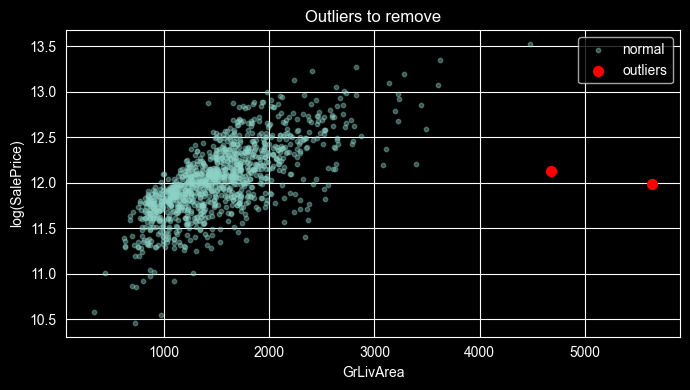

In [98]:
plt.figure(figsize=(7, 4))
plt.scatter(x_t['GrLivArea'], y_t, alpha=0.4, s=10, label='normal')
outlier_vis = (x_t['GrLivArea'] > 4000) & (y_t < np.log1p(300_000))
plt.scatter(x_t.loc[outlier_vis, 'GrLivArea'], y_t[outlier_vis],
            color='red', s=50, zorder=5, label='outliers')
plt.xlabel('GrLivArea')
plt.ylabel('log(SalePrice)')
plt.title('Outliers to remove')
plt.legend()
plt.tight_layout()
plt.savefig('plots/outliers.png', dpi=100)
plt.show()

In [99]:
is_outlier= (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
clean_train = train.loc[~is_outlier].reset_index(drop=True)
print("removed : ", is_outlier.sum())


removed :  2


In [127]:
y= np.log1p(clean_train['SalePrice'])
x= clean_train.drop(columns=["SalePrice" ,"Id"])

x_t,x_v,y_t,y_v = train_test_split(x,y,test_size=0.2,random_state=42)

In [128]:
missing = x_t.isna().mean()


In [129]:
missing

MSSubClass       0.000000
MSZoning         0.000000
LotFrontage      0.182676
LotArea          0.000000
Street           0.000000
                   ...   
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
Length: 79, dtype: float64

In [130]:
high_missing = missing[missing>0.70].index.tolist()

In [131]:
high_missing

['Alley', 'PoolQC', 'Fence', 'MiscFeature']

In [132]:
x_t= x_t.drop(columns=high_missing)
x_v= x_v.drop(columns=high_missing)

print("dropped : ", high_missing)

dropped :  ['Alley', 'PoolQC', 'Fence', 'MiscFeature']


In [138]:
filler = pre.NAFiller()
x_t_na = filler.fit_transform(x_t,y_t)
x_v_na = filler.transform(x_v)



In [142]:
x_v_na


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1320,60,RL,107.0,10186,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,39,0,0,0,0,0,6,2010,WD,Normal
836,160,RM,21.0,1680,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,11,2008,WD,Normal
413,30,RM,56.0,8960,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,130,0,0,0,0,3,2010,WD,Normal
522,50,RM,50.0,5000,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,24,36,0,0,0,0,10,2006,WD,Normal
1035,20,RL,89.0,12898,Pave,IR1,HLS,AllPub,Inside,Gtl,...,0,0,0,0,0,0,9,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,30,RM,50.0,5925,Pave,Reg,Bnk,AllPub,Inside,Gtl,...,72,0,0,0,0,0,3,2007,WD,Alloca
1359,20,RL,124.0,16158,Pave,IR1,Low,AllPub,Inside,Mod,...,36,0,0,0,0,0,6,2009,WD,Normal
1413,120,RL,51.0,3635,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,20,0,0,0,0,0,5,2009,WD,Normal
650,70,RL,60.0,9084,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,10,2009,WD,Normal


In [143]:
# training.train_model(x_t_na, y_t,x_v_na ,y_v, "cleaned",Ridge(),"neg_root_mean_squared_error")

feature engineering


In [145]:
from ML_Assignment_1.mapping import ORDINAL_COLUMNS

qual = pre.QualityEncoder(ORDINAL_COLUMNS)
x_t_qual = qual.fit_transform(x_t_na)
x_v_qual = qual.transform(x_v_na)

In [146]:
x_t_qual

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,20,RL,70.0,8400,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,6,2010,WD,Normal
1065,60,RL,59.0,7837,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,40,0,0,0,0,0,5,2009,WD,Normal
864,20,RL,69.0,8750,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,8,2009,WD,Normal
798,50,RL,60.0,7200,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,264,0,0,0,0,6,2007,WD,Normal
380,50,RL,50.0,5000,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,242,0,0,0,0,5,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,70,RM,60.0,6882,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,115,0,0,0,0,3,2007,WD,Normal
1130,20,RL,63.0,10712,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,28,0,0,0,0,0,9,2007,Oth,Abnorml
1294,20,RL,70.0,8400,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,11,2006,WD,Normal
860,190,RL,75.0,11625,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,4,2010,WD,Normal


In [149]:
cat_cols = x_t_qual.select_dtypes(include="object").columns


C:\Users\lukas\AppData\Local\Temp\ipykernel_30660\438275464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_t_qual.select_dtypes(include="object").columns


In [150]:
cat_cols


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir',
       'Electrical', 'GarageType', 'SaleType', 'SaleCondition'],
      dtype='str')

In [151]:
cardinal= x_t_qual[cat_cols].nunique()

In [152]:
cardinal


MSZoning          5
Street            2
LotShape          4
LandContour       4
Utilities         2
LotConfig         5
LandSlope         3
Neighborhood     25
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
RoofStyle         6
RoofMatl          6
Exterior1st      15
Exterior2nd      16
MasVnrType        3
Foundation        6
Heating           6
CentralAir        2
Electrical        4
GarageType        6
SaleType          9
SaleCondition     6
dtype: int64

In [153]:
woe_cols = cardinal[cardinal>5].index.tolist()

In [154]:
woe_cols

['Neighborhood',
 'Condition1',
 'Condition2',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'Foundation',
 'Heating',
 'GarageType',
 'SaleType',
 'SaleCondition']

In [155]:
woe_enc= pre.WOEEncoder(columns=woe_cols)

In [157]:
x_t_woe=woe_enc.fit_transform(x_t_qual,y_t)
x_v_woe=woe_enc.transform(x_v_qual)

In [158]:
ohe = pre.OneHotEncoderSafe()
x_t_ohe= ohe.fit_transform(x_t_woe)
x_v_ohe= ohe.transform(x_v_woe)

In [159]:
x_t_ohe

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,MasVnrType_BrkFace,MasVnrType_Stone,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_SBrkr
0,20,70.0,8400,5,6,1957,1957,0.0,3,4,...,0,0,0,0,1,0,1,0,0,1
1,60,59.0,7837,6,7,1993,1994,0.0,4,3,...,0,0,0,0,1,0,1,0,0,1
2,20,69.0,8750,5,6,1970,1970,76.0,3,3,...,0,0,0,0,1,0,1,0,0,1
3,50,60.0,7200,5,7,1937,1950,252.0,3,3,...,0,0,0,0,1,0,1,0,0,1
4,50,50.0,5000,5,6,1924,1950,0.0,3,3,...,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161,70,60.0,6882,6,7,1914,2006,0.0,3,3,...,0,0,0,0,1,0,1,0,0,1
1162,20,63.0,10712,5,5,1991,1992,0.0,3,3,...,0,0,0,0,1,0,1,0,0,1
1163,20,70.0,8400,5,5,1968,1968,168.0,3,3,...,0,0,0,0,1,0,1,0,0,1
1164,190,75.0,11625,5,4,1965,1965,0.0,3,3,...,1,0,0,0,1,0,1,0,0,1


In [160]:
x_t_ohe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 92 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MSSubClass          1166 non-null   int64  
 1   LotFrontage         1166 non-null   float64
 2   LotArea             1166 non-null   int64  
 3   OverallQual         1166 non-null   int64  
 4   OverallCond         1166 non-null   int64  
 5   YearBuilt           1166 non-null   int64  
 6   YearRemodAdd        1166 non-null   int64  
 7   MasVnrArea          1166 non-null   float64
 8   ExterQual           1166 non-null   int64  
 9   ExterCond           1166 non-null   int64  
 10  BsmtQual            1166 non-null   int64  
 11  BsmtCond            1166 non-null   int64  
 12  BsmtExposure        1166 non-null   int64  
 13  BsmtFinType1        1166 non-null   int64  
 14  BsmtFinSF1          1166 non-null   int64  
 15  BsmtFinType2        1166 non-null   int64  
 16  BsmtFinSF2       

In [161]:
training.train_model(x_t_ohe,y_t,x_v_ohe,y_v, "feature egineered", Ridge(),"neg_root_mean_squared_error")

2026/04/13 21:29:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 21:29:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  feature egineered
cv_rmsle_mean:  0.11914504658402876
cv_rmsle_std:  0.012255709329414017
train_rmsle:  0.10518155885893114
validation_rmsle:  0.11737293261573797
🏃 View run feature egineered at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/a1eb3209db504d43a59280fd81a4f6ef
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.11737293261573797)

In [163]:
# now lets add some new features
feat_add = pre.FeatureAdder()
x_t_fe =feat_add.fit_transform(x_t_ohe)
x_v_fe = feat_add.transform(x_v_ohe)


In [164]:
x_t_fe.shape

(1166, 103)

In [165]:
x_t_ohe.shape

(1166, 92)

In [167]:
x_t_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Columns: 103 entries, MSSubClass to HasFireplace
dtypes: float64(17), int64(86)
memory usage: 938.4 KB


In [168]:
training.train_model(x_t_fe,y_t,x_v_fe,y_v, "feature egineered + new fearures", Ridge(),"neg_root_mean_squared_error")

2026/04/13 21:36:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 21:36:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  feature egineered + new fearures
cv_rmsle_mean:  0.11981198750140287
cv_rmsle_std:  0.011659313124627356
train_rmsle:  0.10488171695934201
validation_rmsle:  0.11733921091482058
🏃 View run feature egineered + new fearures at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/f22ef89fd1cc493fb2c01be688d9a959
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.11733921091482058)

In [171]:
# now add scaler
scaler = StandardScaler()
x_t_sc= pd.DataFrame(scaler.fit_transform(x_t_fe), columns=x_t_fe.columns)
x_v_sc= pd.DataFrame(scaler.transform(x_v_fe), columns=x_v_fe.columns)




In [173]:
training.train_model(x_t_sc,y_t,x_v_sc,y_v, "feature egineered + new features+ scaler", Ridge(),"neg_root_mean_squared_error")

2026/04/13 21:44:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  feature egineered + new features+ scaler
cv_rmsle_mean:  0.1193674255650563
cv_rmsle_std:  0.011115079981903638
train_rmsle:  0.10390229074525907
validation_rmsle:  0.1148530016023924
🏃 View run feature egineered + new features+ scaler at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/cf40073dd0cb4b3c9f808d33932cdd18
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.1148530016023924)

In [176]:
training.train_model(x_t_sc,y_t,x_v_sc,y_v, "feature egineered + new features+ scaler", DecisionTreeRegressor(max_depth=3,random_state=42),"neg_root_mean_squared_error")

2026/04/13 21:48:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  feature egineered + new features+ scaler
cv_rmsle_mean:  0.21304336689728123
cv_rmsle_std:  0.00988931183696315
train_rmsle:  0.19355401673426365
validation_rmsle:  0.21369383922825966
🏃 View run feature egineered + new features+ scaler at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/9f804870c55848ed82fee4f8e22f21e8
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.21369383922825966)

feature selection


In [177]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator=Ridge(), n_features_to_select=30)
rfe.fit(x_t_sc,y_t)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",Ridge()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",30
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solutio

In [179]:
rfe_cols= x_t_sc.columns[rfe.support_].tolist()
x_t_sc=x_t_sc[rfe_cols]
x_v_sc=x_v_sc[rfe_cols]
print("rfe cols", rfe_cols)

rfe cols ['LotArea', 'OverallQual', 'OverallCond', 'BsmtQual', 'BsmtFinSF1', 'TotalBsmtSF', '2ndFlrSF', 'GrLivArea', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageArea', 'PoolArea', 'Neighborhood_woe', 'Foundation_woe', 'SaleCondition_woe', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'CentralAir_Y', 'TotalPorchSF', 'TotalBathrooms', 'HouseAge', 'RemodAge', 'QualityXArea', 'HasPool', 'HasGarage']


In [180]:
training.train_model(x_t_sc,y_t,x_v_sc,y_v, "RFE", Ridge(),"neg_root_mean_squared_error")

2026/04/13 21:57:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  RFE
cv_rmsle_mean:  0.11509999608217403
cv_rmsle_std:  0.010108821778056122
train_rmsle:  0.10967311954699567
validation_rmsle:  0.11832362883867843
🏃 View run RFE at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/33ea58e8c09548e3b956208e0ba13559
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.11832362883867843)

In [182]:
corr = x_t_sc.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop= set()
for col in upper.columns:
    for p in upper.index[upper[col]>0.85].tolist():
        dcol = p if abs(x_t_sc[col].corr(y_t))>= abs(x_t_sc[p].corr(y_t)) else col
        drop.add(dcol)
corr_cols= [c for c in rfe_cols if c not in drop]
x_t_sc = x_t_sc[corr_cols]
x_v_sc = x_v_sc[corr_cols]
print("correlation dropped : ", drop)


correlation dropped :  {'PoolArea', 'QualityXArea'}


In [189]:
training.train_model(x_t_sc,y_t,x_v_sc,y_v, "RFE+corr", Ridge(),"neg_root_mean_squared_error")

2026/04/13 22:09:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  RFE+corr
cv_rmsle_mean:  0.11597817808854802
cv_rmsle_std:  0.009461493975002566
train_rmsle:  0.11076641200761045
validation_rmsle:  0.11718370440866899
🏃 View run RFE+corr at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/043d7ff183b647669e2d37e577f6de07
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


np.float64(0.11718370440866899)

training

In [193]:
for i in range(10):
    alpha = 0.0001*(10**i)
    name = f"Ridge , alpha = {alpha}"
    training.train_model(x_t_sc,y_t,x_v_sc,y_v, name, Ridge(alpha=alpha,max_iter=10000),"neg_root_mean_squared_error")

2026/04/13 22:15:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 0.0001
cv_rmsle_mean:  0.11605655847792931
cv_rmsle_std:  0.009263299955306795
train_rmsle:  0.1107590831404671
validation_rmsle:  0.1169968058812433
🏃 View run Ridge , alpha = 0.0001 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/2845b667fca74106aa6c5896438f07c4
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:15:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 0.001
cv_rmsle_mean:  0.1160564700541142
cv_rmsle_std:  0.009263499601090124
train_rmsle:  0.11075908314858503
validation_rmsle:  0.1169969677391441
🏃 View run Ridge , alpha = 0.001 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/e64ae7b757724de49448fe985618c8b5
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:16:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

name :  Ridge , alpha = 1000.0
cv_rmsle_mean:  0.13383353781282098
cv_rmsle_std:  0.0109240610905355
train_rmsle:  0.12788884242678072
validation_rmsle:  0.14614094121254326
🏃 View run Ridge , alpha = 1000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/1ecde020f90247749414f93072f0e185
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:18:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 10000.0
cv_rmsle_mean:  0.26091904966442986
cv_rmsle_std:  0.016257065939275096
train_rmsle:  0.24276228106497955
validation_rmsle:  0.2601562249087223
🏃 View run Ridge , alpha = 10000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/e47c519576bf4fdd9c9d5229418fb23c
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:18:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 100000.0
cv_rmsle_mean:  0.37499449369221166
cv_rmsle_std:  0.018145100260729803
train_rmsle:  0.3694794396623326
validation_rmsle:  0.3837908742627132
🏃 View run Ridge , alpha = 100000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/923734643f1e46a5b2bf618024e29d56
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


In [194]:
from sklearn.linear_model import Lasso

for i in range(10):
    alpha = 0.0001*(10**i)
    name = f"Ridge , alpha = {alpha}"
    training.train_model(x_t_sc,y_t,x_v_sc,y_v, name, Lasso(alpha=alpha,max_iter=10000),"neg_root_mean_squared_error")

2026/04/13 22:18:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 0.0001
cv_rmsle_mean:  0.11603937615346496
cv_rmsle_std:  0.009534443436476468
train_rmsle:  0.11077136094366362
validation_rmsle:  0.11722301622904044
🏃 View run Ridge , alpha = 0.0001 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/648a57fb30eb42788eea3a698862192c
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:19:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 0.001
cv_rmsle_mean:  0.1168917152840641
cv_rmsle_std:  0.011165023484467875
train_rmsle:  0.11193855418142316
validation_rmsle:  0.12176749390411847
🏃 View run Ridge , alpha = 0.001 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/48b1055c86e846849e1466d6e5a21f51
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:19:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

name :  Ridge , alpha = 1000.0
cv_rmsle_mean:  0.3971310134919698
cv_rmsle_std:  0.01835676338715595
train_rmsle:  0.39676936838600346
validation_rmsle:  0.4105933660772451
🏃 View run Ridge , alpha = 1000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/f27b1520fcaf45179c374fe41b145962
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:21:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 10000.0
cv_rmsle_mean:  0.3971310134919698
cv_rmsle_std:  0.01835676338715595
train_rmsle:  0.39676936838600346
validation_rmsle:  0.4105933660772451
🏃 View run Ridge , alpha = 10000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/4aaa16310f0c4768ad53f424845e2573
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:22:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Ridge , alpha = 100000.0
cv_rmsle_mean:  0.3971310134919698
cv_rmsle_std:  0.01835676338715595
train_rmsle:  0.39676936838600346
validation_rmsle:  0.4105933660772451
🏃 View run Ridge , alpha = 100000.0 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/93f62ff9cdbf47aeaa6317f53f23366c
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


In [195]:
for d in [2,3,4,6,8,10, None]:
    name = f"Dtree, depth = {d}"
    training.train_model(x_t_sc,y_t,x_v_sc,y_v, name, DecisionTreeRegressor(max_depth=d,random_state=42),"neg_root_mean_squared_error")

2026/04/13 22:22:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Dtree, depth = 2
cv_rmsle_mean:  0.25577631149160823
cv_rmsle_std:  0.01906518682243751
train_rmsle:  0.24593943125652656
validation_rmsle:  0.26245343612236305
🏃 View run Dtree, depth = 2 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/65296f8461b742eaacb1e4bcff1a9e84
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:23:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Dtree, depth = 3
cv_rmsle_mean:  0.2279744946404585
cv_rmsle_std:  0.01619626403761543
train_rmsle:  0.20998687217796155
validation_rmsle:  0.22642097347397508
🏃 View run Dtree, depth = 3 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/67465759d054412e8be642d3631a6b41
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:23:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

name :  Dtree, depth = 8
cv_rmsle_mean:  0.2028349167420252
cv_rmsle_std:  0.011592509952049992
train_rmsle:  0.09244184664885856
validation_rmsle:  0.19051987396958106
🏃 View run Dtree, depth = 8 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/b2c6a9e2b6104bd0ad2329ddca92407a
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:24:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Dtree, depth = 10
cv_rmsle_mean:  0.20544396109537222
cv_rmsle_std:  0.013373455815425058
train_rmsle:  0.05878116164491013
validation_rmsle:  0.1866759012682267
🏃 View run Dtree, depth = 10 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/3d508ac1b3844677946f63bb099cba61
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:24:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  Dtree, depth = None
cv_rmsle_mean:  0.20620832233699163
cv_rmsle_std:  0.013944465681202858
train_rmsle:  0.0016588974779374
validation_rmsle:  0.20221525606736765
🏃 View run Dtree, depth = None at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/9ee85e64f4804a0ba3853c267fd5c948
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


In [199]:
confs = [
    {"n_estimators":300, "max_depth" : 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators":400, "max_depth" : 4, "learning_rate": 0.15, "subsample": 0.75},
    {"n_estimators":500, "max_depth" : 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators":600, "max_depth" : 6, "learning_rate": 0.03, "subsample": 0.9},
    {"n_estimators":700, "max_depth" : 3, "learning_rate": 0.1, "subsample": 0.8},
    {"n_estimators":200, "max_depth" : 5, "learning_rate": 0.1, "subsample": 0.7}
]

for con in confs:
    name =f"xgb , n={con["n_estimators"]}, max_d = {con["max_depth"]} , lr = {con["learning_rate"]} , subsample = {con["subsample"]}"
    training.train_model(x_t_sc,y_t,x_v_sc,y_v, name, XGBRegressor(**con,random_state=42,eval_metric='rmse',verbosity=0 ),"neg_root_mean_squared_error")


2026/04/13 22:30:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  xgb , n=300, max_d = 3 , lr = 0.05 , subsample = 0.8
cv_rmsle_mean:  0.12177164019218034
cv_rmsle_std:  0.009302653248107126
train_rmsle:  0.07436676168848226
validation_rmsle:  0.12125872834295377
🏃 View run xgb , n=300, max_d = 3 , lr = 0.05 , subsample = 0.8 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/2bf126683e80489b95a7edfe7efcf6da
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:30:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  xgb , n=400, max_d = 4 , lr = 0.15 , subsample = 0.75
cv_rmsle_mean:  0.1313048928696825
cv_rmsle_std:  0.008309887565687757
train_rmsle:  0.015016960059343361
validation_rmsle:  0.12595505617144295
🏃 View run xgb , n=400, max_d = 4 , lr = 0.15 , subsample = 0.75 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/ebfb6fb14a244838a1d5492b6f7f1f61
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:31:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

name :  xgb , n=600, max_d = 6 , lr = 0.03 , subsample = 0.9
cv_rmsle_mean:  0.1266466497831927
cv_rmsle_std:  0.00960937221538835
train_rmsle:  0.014846204771493735
validation_rmsle:  0.12683362465192602
🏃 View run xgb , n=600, max_d = 6 , lr = 0.03 , subsample = 0.9 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/7e4481addcc34fe1a4adce70aed8fc9d
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:31:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  xgb , n=700, max_d = 3 , lr = 0.1 , subsample = 0.8
cv_rmsle_mean:  0.1247568282612231
cv_rmsle_std:  0.006946977259134165
train_rmsle:  0.03148063956407163
validation_rmsle:  0.12217081921319914
🏃 View run xgb , n=700, max_d = 3 , lr = 0.1 , subsample = 0.8 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/1d14f035dacb40968eed32aff44653bf
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


2026/04/13 22:32:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


name :  xgb , n=200, max_d = 5 , lr = 0.1 , subsample = 0.7
cv_rmsle_mean:  0.12543907416116615
cv_rmsle_std:  0.006882554641666141
train_rmsle:  0.02648437913863439
validation_rmsle:  0.12672249163503024
🏃 View run xgb , n=200, max_d = 5 , lr = 0.1 , subsample = 0.7 at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0/runs/8c22a6e3d9b24fbbb49945cc998cba03
🧪 View experiment at: https://dagshub.com/lukaLomadze/ML_Assignment_1.mlflow/#/experiments/0


In [207]:
all_runs = mlflow.search_runs(
    experiment_names=['Default'],
    order_by=['metrics.val_rmsle ASC']
)
print(all_runs[[
    'tags.mlflow.runName',
    'metrics.cv_rmsle_mean', 'metrics.train_rmsle',
    'metrics.validation_rmsle', 'metrics.overfit'
]].head(10).to_string(index=False))

                                  tags.mlflow.runName  metrics.cv_rmsle_mean  metrics.train_rmsle  metrics.validation_rmsle  metrics.overfit
  xgb , n=200, max_d = 5 , lr = 0.1 , subsample = 0.7               0.125439             0.026484                  0.126722         0.100238
  xgb , n=700, max_d = 3 , lr = 0.1 , subsample = 0.8               0.124757             0.031481                  0.122171         0.090690
 xgb , n=600, max_d = 6 , lr = 0.03 , subsample = 0.9               0.126647             0.014846                  0.126834         0.111987
 xgb , n=500, max_d = 3 , lr = 0.05 , subsample = 0.8               0.121261             0.061356                  0.120682         0.059326
xgb , n=400, max_d = 4 , lr = 0.15 , subsample = 0.75               0.131305             0.015017                  0.125955         0.110938
 xgb , n=300, max_d = 3 , lr = 0.05 , subsample = 0.8               0.121772             0.074367                  0.121259         0.046892
             

In [208]:
best_run_id = all_runs.iloc[0]['run_id']
print('Best run:', all_runs.iloc[0]['tags.mlflow.runName'])

mv = mlflow.register_model(f'runs:/{best_run_id}/model', 'house-prices-best')

client = mlflow.tracking.MlflowClient()
client.transition_model_version_stage(
    name='house-prices-best',
    version=mv.version,
    stage='Production',
    archive_existing_versions=True
)
print(f'Registered version {mv.version} → Production')

Best run: xgb , n=200, max_d = 5 , lr = 0.1 , subsample = 0.7


Registered model 'house-prices-best' already exists. Creating a new version of this model...


MlflowException: Unable to find a logged_model with artifact_path model under run 8c22a6e3d9b24fbbb49945cc998cba03